In [110]:
import pandas as pd
import matplotlib.pyplot as plt

In [111]:
acc_df = pd.read_csv("/Users/rblc/create/work/elte/polar/data/acc_10min.csv")
ecg_df = pd.read_csv("/Users/rblc/create/work/elte/polar/data/ecg_10min.csv")

In [112]:
acc_df.columns

Index(['packet_id', 'device_time', 'host_time', 'x', 'y', 'z'], dtype='str')

In [113]:
acc_df.head()

,packet_id,device_time,host_time,x,y,z
0,0,5.996184e+11,1.780932e+12,-611,681,440
1,0,5.996184e+11,1.780932e+12,-609,675,440
2,0,5.996184e+11,1.780932e+12,-609,675,448
3,0,5.996184e+11,1.780932e+12,-609,677,448
4,0,5.996184e+11,1.780932e+12,-608,676,445


In [114]:
ACC_DT = 1 / 200
ACC_DT_MS = ACC_DT * 1000

acc_df["sample_idx"] = acc_df.groupby("packet_id").cumcount()
packet_sizes = acc_df.groupby("packet_id")["packet_id"].transform("size")

acc_df["sample_time"] = (
    acc_df["device_time"]
    - ((packet_sizes - 1 - acc_df["sample_idx"]) * ACC_DT_MS)
)

acc_df["time_ms"] = acc_df["sample_time"] - acc_df["sample_time"].min()

In [115]:
packet_sizes

0         36
1         36
2         36
3         36
4         36
          ..
118975    36
118976    36
118977    36
118978    36
118979    36
Name: packet_id, Length: 118980, dtype: int64

In [116]:
acc_df

,packet_id,device_time,host_time,x,y,z,sample_idx,sample_time,time_ms
0,0,5.996184e+11,1.780932e+12,-611,681,440,0,5.996184e+11,0.000000
1,0,5.996184e+11,1.780932e+12,-609,675,440,1,5.996184e+11,5.000000
2,0,5.996184e+11,1.780932e+12,-609,675,448,2,5.996184e+11,10.000000
3,0,5.996184e+11,1.780932e+12,-609,677,448,3,5.996184e+11,15.000000
4,0,5.996184e+11,1.780932e+12,-608,676,445,4,5.996184e+11,20.000000
...,...,...,...,...,...,...,...,...,...
118975,3304,5.996190e+11,1.780932e+12,-1013,80,-166,31,5.996190e+11,599993.034546
118976,3304,5.996190e+11,1.780932e+12,-1041,73,-158,32,5.996190e+11,599998.034546
118977,3304,5.996190e+11,1.780932e+12,-1052,52,-133,33,5.996190e+11,600003.034546
118978,3304,5.996190e+11,1.780932e+12,-1053,36,-103,34,5.996190e+11,600008.034546


In [117]:
pkt = (
    acc_df.groupby("packet_id")
    .agg(
        device_time=("device_time", "first"),
        host_time=("host_time", "first"),
    )
    .reset_index()
)
pkt["offset"] = pkt["host_time"] - pkt["device_time"]
pkt["offset"].describe()

count    3.305000e+03
mean     1.181313e+12
std      2.572810e+01
min      1.181313e+12
25%      1.181313e+12
50%      1.181313e+12
75%      1.181313e+12
max      1.181313e+12
Name: offset, dtype: float64

<Axes: xlabel='packet_id'>

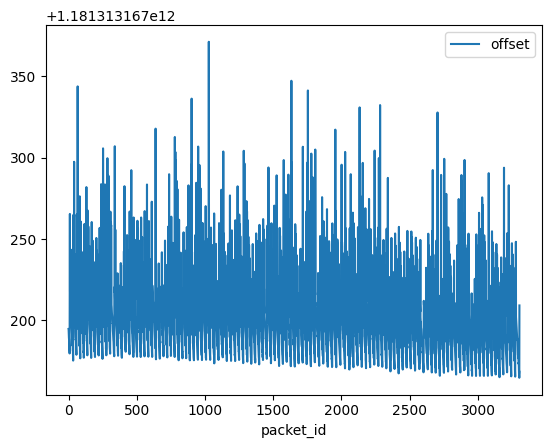

In [118]:
pkt.plot(x="packet_id", y="offset")

In [119]:
ECG_DT = 1 / 130
ECG_DT_MS = ECG_DT * 1000

ecg_df["sample_idx"] = ecg_df.groupby("packet_id").cumcount()
packet_sizes = ecg_df.groupby("packet_id")["packet_id"].transform("size")

ecg_df["sample_time"] = (
    ecg_df["device_time"]
    - ((packet_sizes - 1 - ecg_df["sample_idx"]) * ECG_DT_MS)
)

ecg_df["time_ms"] = ecg_df["sample_time"] - ecg_df["sample_time"].min()

In [120]:
packet_sizes

0        73
1        73
2        73
3        73
4        73
         ..
77959    73
77960    73
77961    73
77962    73
77963    73
Name: packet_id, Length: 77964, dtype: int64